In [95]:
import os
import cupy as cp
import math
import pickle
import random
import matplotlib.pyplot as plt
from model.network import Network

## Loading the Data

In [96]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [97]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [98]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

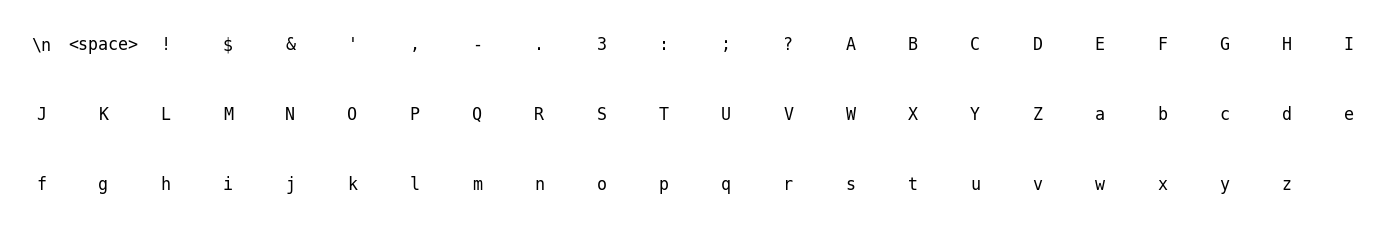

In [99]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [100]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [101]:
embedding_dim = 128
hidden_size = 512
hidden_2_size = 256

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "Recurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Dropout", "rate": 0.2},
    {"type": "Recurrent", "input_size": hidden_size, "num_neurons": hidden_2_size},
    {"type": "Dropout", "rate": 0.2},
    {"type": "Softmax", "input_size": hidden_2_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()

Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 128)
  Parameters: 8,320

Layer 2: RecurrentLayer
  Weights Shape: (128, 512) | State Weights Shape: (512, 512) | Biases Shape: (512,)
  Parameters: 328,192

Layer 3: DropoutLayer
  Rate: 0.2

Layer 4: RecurrentLayer
  Weights Shape: (512, 256) | State Weights Shape: (256, 256) | Biases Shape: (256,)
  Parameters: 196,864

Layer 5: DropoutLayer
  Rate: 0.2

Layer 6: SoftmaxLayer
  Weights Shape: (256, 65) | Biases Shape: (65,)
  Parameters: 16,705

Total Parameters: 550,081


## Training the Model

In [102]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [103]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [104]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [105]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
    clip_value: float | None = None,
) -> float:
    network.set_training(True)
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    network.set_training(False)
    return math.exp(total_loss / total_steps)


In [106]:
hyperparameters = {
    "sequence_length": 64,
    "batch_size": 64,
    "epochs": 1000,
    "train_steps_per_epoch": 4096,
    "validation_steps": 1024,
    "base_learning_rate": 3e-7,
    "min_learning_rate": 3e-10,
    "weight_decay_lambda": 1e-4,
    "momentum": 0.9,
    "early_stopping_patience": 25,
    "clip_value": 5.0,
    "checkpoint_interval": 50,
}

print(hyperparameters)

{'sequence_length': 64, 'batch_size': 64, 'epochs': 1000, 'train_steps_per_epoch': 4096, 'validation_steps': 1024, 'base_learning_rate': 3e-07, 'min_learning_rate': 3e-10, 'weight_decay_lambda': 0.0001, 'momentum': 0.9, 'early_stopping_patience': 25, 'clip_value': 5.0, 'checkpoint_interval': 50}


In [107]:
CHECKPOINT_PATH = "rnn_checkpoint.pkl"

epoch_summaries = []
total_steps = hyperparameters["epochs"] * hyperparameters["train_steps_per_epoch"]
global_step = 0
best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

slice_size = hyperparameters["batch_size"] * hyperparameters["train_steps_per_epoch"]
max_offset = int(x_train_indices.shape[0]) - slice_size

if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, "rb") as file:
        checkpoint = pickle.load(file)
    best_model = checkpoint["model"]
    epoch_summaries = checkpoint["epoch_summaries"]
    best_perplexity = min(summary["test_perplexity"] for summary in epoch_summaries)
    
    network = best_model.clone()
    print(f"Loaded checkpoint, best perplexity: {best_perplexity:.4f}")
else:
    print("No checkpoint found, starting from scratch.")

epoch_offset = len(epoch_summaries)

Loaded checkpoint, best perplexity: 4.1422


In [108]:
def save_checkpoint(model, path):
    with open(path, "wb") as file:
        pickle.dump({
            "model": model,
            "vocabulary": vocabulary,
            "epoch_summaries": epoch_summaries,
        }, file)
    print(f"  Checkpoint saved -> {path}")

In [109]:
for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    offset = random.randint(0, max_offset)
    x_slice = x_train_indices[offset : offset + slice_size]
    y_slice = y_train_indices[offset : offset + slice_size]

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_slice,
        y_indices=y_slice,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        weight_decay_lambda=hyperparameters["weight_decay_lambda"],
        momentum=hyperparameters["momentum"],
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch + epoch_offset,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
        "regularization": train_perplexity / test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if (epoch + epoch_offset) % 10 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += hyperparameters["train_steps_per_epoch"]

    if (epoch + epoch_offset) % hyperparameters["checkpoint_interval"] == 0:
        save_checkpoint(best_model, "rnn_checkpoint.pkl")

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch + epoch_offset} epochs due to no improvement.")
        break

{'epoch': 1042, 'learning_rate': 3e-07, 'train_perplexity': 4.363479090750252, 'test_perplexity': 4.142187799595394, 'regularization': 1.0534237706886378}
{'epoch': 1050, 'learning_rate': 2.999526757641025e-07, 'train_perplexity': 4.362960395172031, 'test_perplexity': 4.142194873283001, 'regularization': 1.0532967493424703}
  Checkpoint saved -> rnn_checkpoint.pkl
{'epoch': 1060, 'learning_rate': 2.997604722838299e-07, 'train_perplexity': 4.374318747244353, 'test_perplexity': 4.142202591320408, 'regularization': 1.0560368911965636}
Early stopping triggered after 1066 epochs due to no improvement.


In [110]:
print(f"Best validation perplexity: {best_perplexity:.4f} at epoch {min(epoch + epoch_offset - hyperparameters['early_stopping_patience'], epoch + epoch_offset)}")

Best validation perplexity: 4.1422 at epoch 1041


In [111]:
save_checkpoint(best_model, "best_rnn_model.pkl")

  Checkpoint saved -> best_rnn_model.pkl


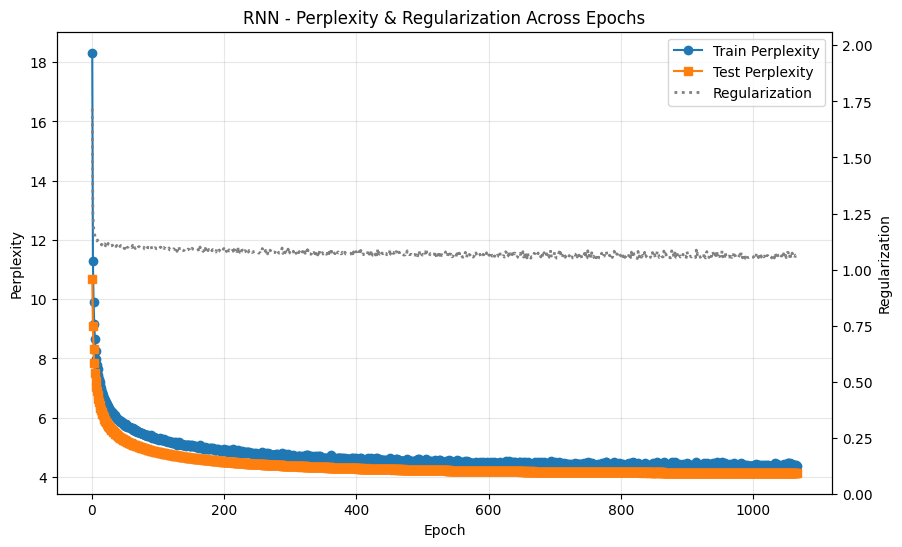

In [112]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
regularizations = [summary["regularization"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, regularizations, color="gray", linestyle=":", linewidth=2, label="Regularization")
ax2.set_ylim(0, max(regularizations) * 1.2)
ax2.set_ylabel("Regularization")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("RNN - Perplexity & Regularization Across Epochs")
plt.show()

In [113]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [118]:
seed_text = "DANIEL"
generated = generate_text(network=best_model, seed_text=seed_text, length=1000, temperature=0.85, print_during=True)

DANIEL:
Bade her, the wife, or measure upon me.

FRIAR Glook:
My leave him rest to his right with herders.

BUSHOM:
The wind promised, by the fair
Clease the sleep? I promise no amfuded
To move the dukese reasons of thy farewell I do me: methinks, make the lordshally set which for Gloucester,
Mistress it lies,
Some to-morrow? I have stroke
To gave me full an envience, presont his rate
To fawring with uncle, Isage, that villain: thy arcute on go:
By scohe to thee honour, and all this instrant thy sith of my stoup a pleasure Norfolk:
Then for sir, my lord, in which time to rememper to hive of my comazed.

Stion, thank them
To make Edward's pity
A prociest of in the pity, as thou new head to the war! and I pience 't it to the misery death, both bring thee this see's of on me means,
And the shrifks to me is that did not happy the best pity
Know thee, sir, the gods to the deeds,
My time it is not.

ANTONIO:
I have stay it is a cannot be better they should never well tullung.
O, 'tis nothing

In [115]:
seed_text = "DANIEL"
generated = generate_text(network=best_model, seed_text=seed_text, length=1000, temperature=0.8, print_during=True)

DANIEL:
I shall as his attended still it is any remember hand,
Wholder than therefore i' the duke of Clarence, I am away to be counting us,
I great still execution.
Farewell, 'twixt your head of mest father osteriest clown with the grace break,
And madam, they have hangs of the king.

SICINIUS:
So spo; a buy the house
Which for my alse side return made necessity.

DUKE OF YORK:
How waitry, come, my lord is he
And see them not be of his heaven, my fair purpose and for.
Graces, none with the person,
and your brother desperate and true world;
To the duke of the beint to our father again, and my lord?

CLARENCE:
Why, he shall be some self,
He, they can dead,
What he doubt hath call thee at the prince of England,
So these, but thou hast to let me a such her!

Nurse:
The worn a asubt and myself.

BENVOLIO:
The side, it is
the king's sentiposhes there?

SICINIUS:
It for the oach,
Affeither of it is a son: I swallow oun death,
Thou wast thou seek at the body to your labour and when the eless
A

In [116]:
seed_text = "DANIEL"
generated = generate_text(network=best_model, seed_text=seed_text, length=1000, temperature=0.75, print_during=True)

DANIEL:
I will do not part is here:
Which, that made him of ere that
Like that I have soon of such a sild, let it is come him descrem, the will so in the love, and state
To say you to let the king, our day to enter.

KING RICHARD III:
Now, but come access to thee.

POMPEY:
Thy rough of your courts are chinks thou hast sure the gates and live.

FLORIZEL:
You say of had the will able and meet.

PETRUCHAM:
I was which death and part
As the corn to deliver in made his.

PETRUCHIO:
Northurse and death,
Here's stake to should thou perhams?

DORCAS:
No, thou wast, that you shall make the brothers are the swords and words of in the Doason, which overbody haste
To better pardon;
The armemily died that
Hath thie he beepy or
Words in do the conveys in the means for the coor of Master:
You love of himself possession from the manute, and from the sughes;
If the news?

ISABELLA:
Can therefore not speak, and be out to such a very propont and proud mercy; I will cleasure and he hath bear doth speak th

In [117]:
seed_text = "DANIEL"
generated = generate_text(network=best_model, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIEL:
The mother, good Sir,
And so well, better must thou sorrow'd but one a makes the new soul to company to all the body and shall have letters of thy lambling enter
To have you have satispainted for the hand.

GREMIO:
They shall pass it is for me had know
Thou didst father of the consingling breakness;
Which no great looks and servant:
My lord, that thou that fearful tongue
In his course all well-say
The sunder of the house, thou art a heaven with our sweet happy that will men in the people,
To have you see this business that I would not live he see
Thy dear son, it is it well day where.

First Servingman:
The marks that shall revolt them so. What, mark so thing to his truth;
Who will have say the time and at soul in the death with me.

KING HENRY VI:
Why I am the tate and so more,
And see to be shall see being a bride,
Before he hath done him.

GLOUCESTER:
Of hence shall one of the resolved of an a since first, and with my deed.
Hull I ne such colour of such a entreat;
Master and